<a href="https://colab.research.google.com/github/Harshithpalan/Python-projects/blob/main/Speech%20%2B%20Vision%20AI%20Assistant.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Speech + Vision AI Assistant 🎤👁️

This notebook combines image capture with generative AI to answer questions about what the camera sees.

In [10]:
try:
  from google import genai
  from google.colab import userdata
  import PIL.Image
  import io
  from IPython.display import display, Javascript
  from google.colab.output import eval_js
  from base64 import b64decode

  # Configure Gemini using the new SDK
  GOOGLE_API_KEY = userdata.get('GOOGLE_API_KEY')
  client = genai.Client(api_key=GOOGLE_API_KEY, http_options={'api_version': 'v1beta'})

  # Based on diagnostics, gemini-2.0-flash is available
  MODEL_ID = 'gemini-2.0-flash'

  print(f'Client configured successfully using {MODEL_ID}.')
except Exception as e:
  print(f'Configuration error: {e}')
  print('\nReminder: Click the Key icon on the left, add "GOOGLE_API_KEY", and enable Notebook Access.')

Client configured successfully using gemini-2.0-flash.


## Camera Capture Utility
This function allows you to take a photo directly from your browser in Colab.

In [2]:
def take_photo(filename='photo.jpg', quality=0.8):
  js = Javascript('''
    async function takePhoto(quality) {
      const div = document.createElement('div');
      const capture = document.createElement('button');
      capture.textContent = 'Capture';
      div.appendChild(capture);

      const video = document.createElement('video');
      video.style.display = 'block';
      const stream = await navigator.mediaDevices.getUserMedia({video: true});

      document.body.appendChild(div);
      div.appendChild(video);
      video.srcObject = stream;
      await video.play();

      // Resize the output to fit the video element.
      google.colab.output.setIframeHeight(document.documentElement.scrollHeight, true);

      // Wait for Capture to be clicked.
      await new Promise((resolve) => capture.onclick = resolve);

      const canvas = document.createElement('canvas');
      canvas.width = video.videoWidth;
      canvas.height = video.videoHeight;
      canvas.getContext('2d').drawImage(video, 0, 0);
      stream.getVideoTracks()[0].stop();
      div.remove();
      return canvas.toDataURL('image/jpeg', quality);
    }
    ''')
  display(js)
  data = eval_js('takePhoto({})'.format(quality))
  binary = b64decode(data.split(',')[1])
  with open(filename, 'wb') as f:
    f.write(binary)
  return filename

## Run the Assistant
Run this cell, click 'Capture', and input your query (simulated as text here, but ready for speech-to-text integration).

Please allow camera access in the browser popup...


<IPython.core.display.Javascript object>

Saved to photo.jpg


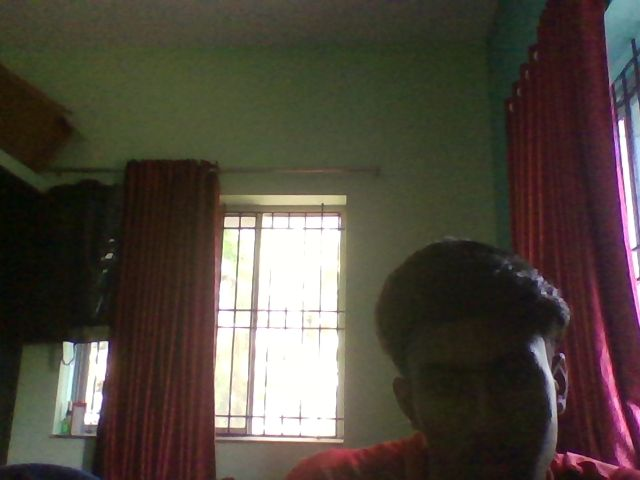

An error occurred: 404 NOT_FOUND. {'error': {'code': 404, 'message': 'models/gemini-1.5-flash is not found for API version v1beta, or is not supported for generateContent. Call ListModels to see the list of available models and their supported methods.', 'status': 'NOT_FOUND'}}


In [7]:
try:
  print('Please allow camera access in the browser popup...')
  filename = take_photo()
  print(f'Saved to {filename}')

  # Display the image
  img = PIL.Image.open(filename)
  display(img)

  # Process with Gemini
  user_query = "What is in front of me?"
  # Note: The new SDK uses client.models.generate_content
  response = client.models.generate_content(
      model=MODEL_ID,
      contents=[user_query, img]
  )

  print(f"\nAI Assistant: {response.text}")
except Exception as err:
  if 'NotAllowedError' in str(err):
    print('Error: Camera permission denied. Please click the camera icon in your browser address bar to reset permissions.')
  else:
    print(f'An error occurred: {err}')